### Project Motivation

For the past year I have been DJ DeSmet. I interviewed and got the role in mid september. I wanted to explore how I have done as DJ DeSmet, because I deeply valued the role, and had a hard time doing it due to my roommate plus other factors involved with playing music.

Music has always been important to me, as it is to most people. When it came to being DJ DeSmet, I wanted to find a way to visualize the work I've done in a nonbiased and more scientific way.

The data I have for this project came from Spotify's developer site, where they sent me my lifelong spotify listening data since I first got spotify in 2022.

### The Actual Data

The listening data I analyzed comes from five JSON files, each representing a full year of my music‑listening history. Each file contains a list of listening events, and I loaded all five files into Python, stored them in a list, and then concatenated them into a single DataFrame for analysis.

### Number of Instances in Each Table
Each JSON file contains a full year of Spotify listening events. The number of rows in each table is:

1. Streaming_History_Audio_2022.json: 164 events
2. Streaming_History_Audio_2023.json: 314 events
3. Streaming_History_Audio_2024.json: 2,201 events
4. Streaming_History_Audio_2025.json: 13,821 events
5. Streaming_History_Audio_2026.json: 5,713 events

After concatenation, the final combined DataFrame contains 22,213 total listening events.

### Attribute Descriptions

Each listening event in the dataset contains metadata exported from Spotify's Extended Streaming History. The key attributes include:

- **ts** — The timestamp of the listening event in ISO format (UTC).
- **platform** — The device and OS version used during playback (e.g., “iOS 15.4.1 (iPhone12,8)”).
- **ms_played** — Total milliseconds the track was played during this session.
- **conn_country** — The country code associated with the connection at the time of playback.
- **master_metadata_track_name** — The name of the track played.
- **master_metadata_album_artist_name** — The primary artist associated with the track.
- **master_metadata_album_album_name** — The album the track belongs to.
- **reason_start** — Why playback began (e.g., “fwdbtn” for forward button).
- **reason_end** — Why playback ended (e.g., “logout”, “endplay”, “fwdbtn”).
- **shuffle** — Boolean indicating whether shuffle mode was enabled.
- **skipped** — Boolean indicating whether the track was skipped.
- **offline** — Whether the track was played offline.
- **incognito_mode** — Whether the session was in Spotify’s private listening mode.

Additionally, I created a new attribute:

- **Minutes played** - Which comes from converting `ms_played` into minutes for easier interpretation.
 
Finally, I removed the unused and irrelevent fields such as `ip_addr` and `spotify_track_uri`

In [1]:
from utils import load_spotify_data

spotify_files = [
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2022.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2023.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2024.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2025.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2026.json"
]

df = load_spotify_data(spotify_files)

### Classification Task

After exploring my general listening habits and analyzing how my daily listening changed before and after becoming DJ Desmet, I extended the project by connecting my listening behavior to the school’s academic calendar. This allowed me to study how my music habits differ between school days and non‑school days.

To do this, I created a new binary classification label:

- **1 — School Day**  
- **0 — Non‑School Day** (weekends, holidays, breaks, etc.)

I merged my Spotify listening data with the academic calendar and computed the total minutes played per day. I also removed long breaks (such as Christmas Break and Spring Break) to avoid skewing the results.

In addition to the school‑day label, I created a second binary label:

- **1 — High Listening Day**
- **0 — Low Listening Day**

This was based on whether the day’s listening time was above or below the median number of minutes played.

Using these labels, I trained two classifiers:

1. **k‑Nearest Neighbors (kNN)**
   - Features: day of week, month, and whether the date was before or after I became DJ Desmet
   - Data was normalized using `StandardScaler`
   - Evaluated using accuracy and a confusion matrix

2. **Decision Tree Classifier**
   - Same features as kNN
   - No scaling required
   - Visualized using `plot_tree` to interpret feature importance

The goal of this classification task is to predict whether a given day will be a **high‑listening day** based on calendar‑related features. This helps reveal how my listening behavior is influenced by school structure, routine, and the shift that occurred after becoming DJ Desmet.

This classification task is meaningful because it connects personal behavior (music listening) with external structure (school schedule), allowing me to analyze how academic routines shape my daily habits.


### Exploratory Data Analysis

Two key features of this project entail:
1. The day I became DJ DeSmet (September 15, 2025)
2. The structure of the school academic calander

### Daily Listening Patterns

I first resampled my listening history into **daily total minutes played**.
To make the analysis meaningful, I applied several filters:
- Removed days with **zero listening**
- Removed **weekends** to focus on school-day routines
- Removed long breaks (winter break, spring break, holidays)
- Split the data into **before** and **after** becoming DJ DeSmet

This allowed me to compare how my listening habits changed over time, and then compare the mean listening time for both periods as well.

In [2]:
from utils import prepare_daily_listening, split_series_before_after

dj_date = "2025-09-15"
break_start = "2025-12-12"
break_end = "2026-01-11"

daily = prepare_daily_listening(
    df,
    break_start=break_start,
    break_end=break_end
)

before, after = split_series_before_after(daily, dj_date)

print(f"Average daily minutes played before DJ: {before.mean():.2f}")
print(f"Average daily minutes played after DJ: {after.mean():.2f}")

Average daily minutes played before DJ: 54.47
Average daily minutes played after DJ: 187.86


### Average Listening Before vs. After DJ Desmet

I visualized these averages using a line graph and a bar chart to compare the two periods.
This helped reveal whether DJing increased or decreased my overall listening time.

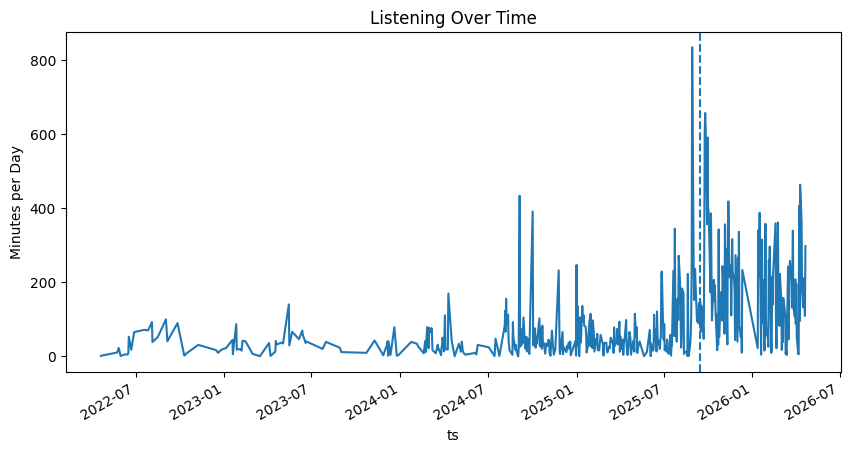

In [3]:
from utils import plot_daily_listening

plot_daily_listening(daily, split_date=dj_date)

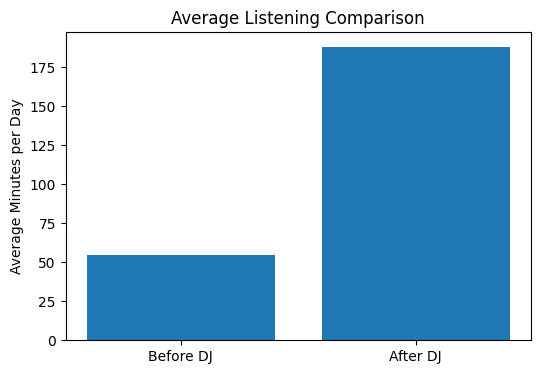

In [4]:
from utils import plot_before_after

means = [before.mean(), after.mean()]

plot_before_after(means[0], means[1])

### Top Artists Before and After DJ Desmet

As a side project, I wanted to see how my musical taste shifted. I calculated the top 10 most‑played artists:

- **Top artists before DJ Desmet**
- **Top artists after DJ Desmet**

I plotted each as a bar chart.  
This allowed me to see how I changed my music taste to try and fit in more music varities that target more people.

As you can see in the second graph, C418 made a huge jump as I started Minecraft Mondays.

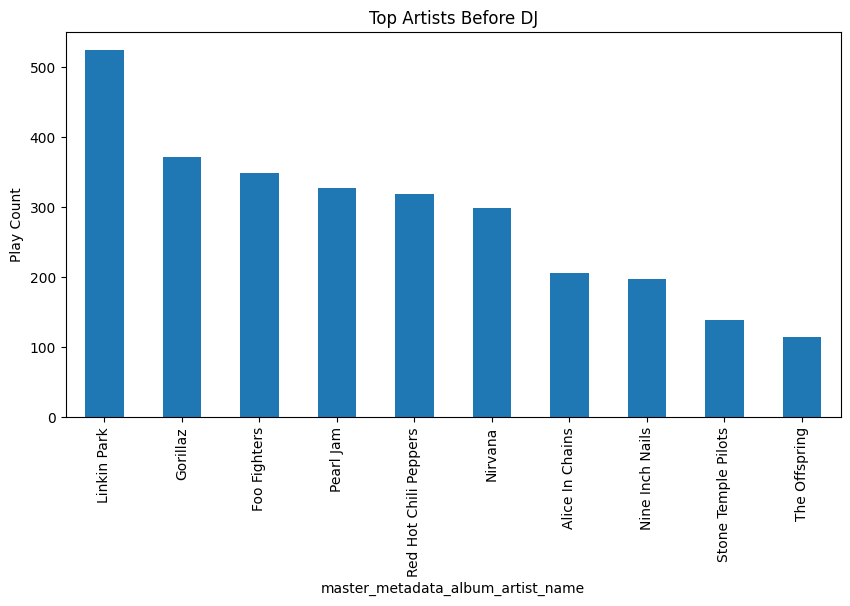

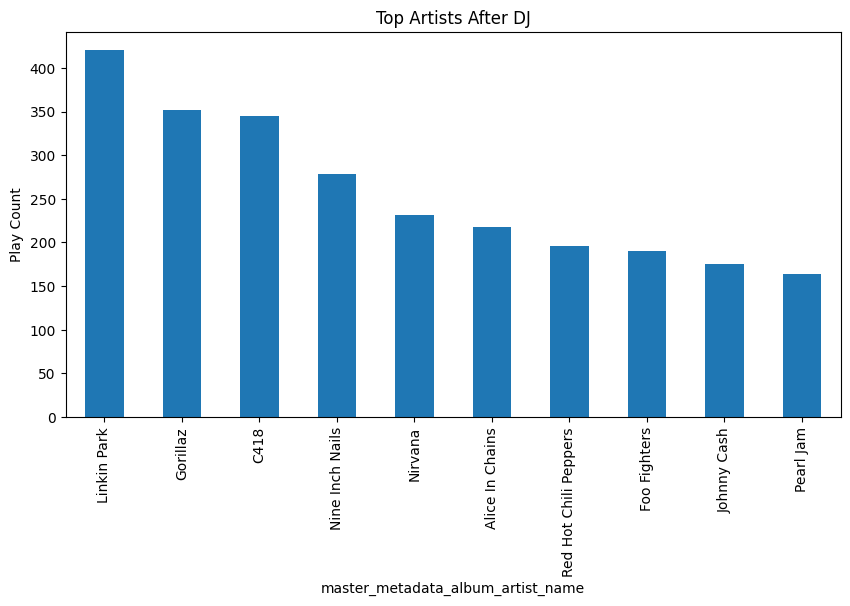

In [5]:
from utils import split_df_before_after, get_top_artists, plot_top_artists

before_df, after_df = split_df_before_after(df, dj_date)

top_before = get_top_artists(before_df, n=10)
top_after = get_top_artists(after_df, n=10)

plot_top_artists(top_before, "Top Artists Before DJ")
plot_top_artists(top_after, "Top Artists After DJ")

### New Artists Discovered After Becoming DJ Desmet

I compared the sets of artists before and after DJ Desmet to find:

- **Artists I listened to only after becoming DJ Desmet**

Then I calculated total minutes played for these new artists and plotted the top 10.  
This shows how DJing influenced my discovery of new music/music I wouldn't typically choose to play on my own time.

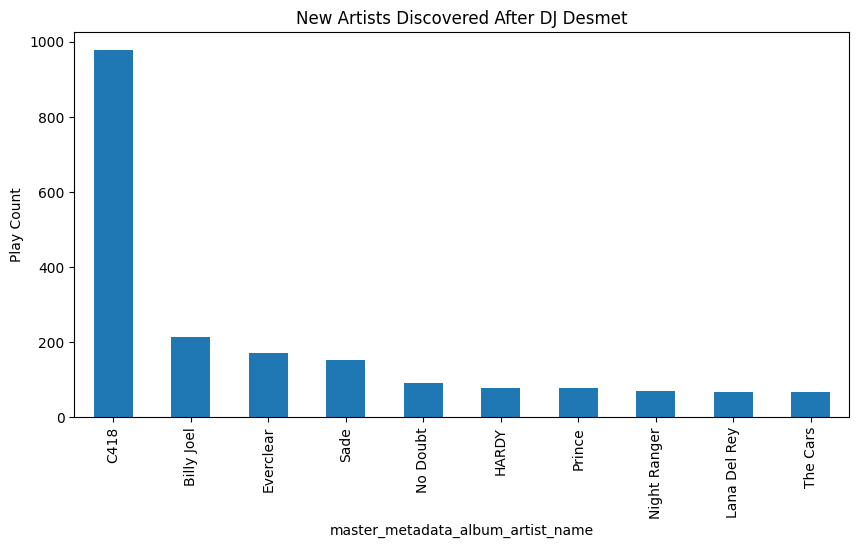

In [6]:
from utils import get_new_artists, plot_top_artists

top_new = get_new_artists(before_df, after_df, n=10)

plot_top_artists(
    top_new,
    "New Artists Discovered After DJ Desmet"
)

### Statistical Hypothesis Testing

To determine whether the change in listening time before and after was statistically significant, I ran a **Welch’s t‑test**:

- H0 (null): My average daily listening time did not change after becoming DJ DeSmet.

- H1 (alt): My average daily listening time did change after becoming DJ Desmet.

The t‑test produced:

- **t‑statistic:** `t_stat`  
- **p‑value:** `p_val`

The p-value ended up being `1.9735369599542327e-19` which is incredibly small, meaning I conclude that the difference was statistically different, and I reject the null hypothesis.

In [8]:
from utils import run_ttest

result = run_ttest(before, after)

print("Before avg:", result["before_mean"])
print("After avg:", result["after_mean"])
print("t-stat:", result["t_stat"])
print("p-value:", result["p_value"])

if result["p_value"] < 0.05:
    print("The difference in listening time before and after DJ Desmet is statistically significant.")
else:
    print("The difference in listening time before and after DJ Desmet is not statistically significant.")

Before avg: 54.47431519174041
After avg: 187.85552860696515
t-stat: -10.57013788108645
p-value: 3.080841049382519e-20
The difference in listening time before and after DJ Desmet is statistically significant.


### Academic Year Listening Behavior

After completing my broad, multi‑year analysis, I shifted into a more focused investigation centered on the 2025–2026 academic year. This dataset is unique because it is the only period where I can align my Spotify listening behavior with the school’s academic calendar. This allows me to view how school routines influence my daily music habits.

To begin this phase, I loaded only the 2025 and 2026 Spotify JSON files and combined them into a single dataset representing the full academic year.

### 1. Converting Raw Listening Events into Daily Totals

Spotify’s extended streaming history records **individual listening events**, not daily summaries.  
To understand my behavior at the day level, I:

- converted timestamps to datetime
- calculated minutes played
- resampled the data into **daily total listening minutes**

This transforms the dataset from thousands of small events into a clean time series of daily listening behavior.
Daily totals are essential because the academic calendar is defined at the day level (school day, weekend, break, holiday).

### 2. Aligning Listening Data with the Academic Calendar

I merged my daily listening totals with the school’s academic calendar, which includes:

- first day of school
- school days
- weekends
- holidays
- Winter Break
- Spring Break
- other no‑school days

This merge adds **context** to each day.  
Instead of just knowing “I listened 45 minutes on October 3,” I now know:

- whether it was a school day
- whether it was a weekend  
- whether it was during a break  
- whether it was before or after becoming DJ Desmet  

This contextual information is what makes classification possible.

### 3. Removing Breaks and Holidays

Break periods (like Winter Break and Spring Break) create **artificial dips** in listening behavior.  
These dips are not caused by changes in my habits, they’re caused by the school calendar.

To avoid skewing the analysis, I removed:

- Winter Break
- Spring Break  
- Christmas Break 
- holidays

In [10]:
from utils import load_spotify_data

academic_year_files = [
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2025.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2026.json"
]

spotify_academic = load_spotify_data(academic_year_files)

### Timestamp and Duration Cleaning

Before analyzing the academic-year dataset, I needed to clean two key columns: the timestamp and the listening duration. I pretty much did the exact same as before.

In [11]:
from utils import load_spotify_data

spotify_academic = load_spotify_data(academic_year_files)

In [12]:
academic_daily = (
    spotify_academic.set_index("ts")
                    .resample("D")["minutes_played"]
                    .sum()
)

before, after = split_series_before_after(academic_daily, dj_date)

In [15]:
from utils import get_daily_listening  # optional, if you regenerated it here
import pandas as pd

first_day = pd.to_datetime("2025-08-14")

academic_daily = academic_daily[academic_daily.index >= first_day]

### Merging Daily Listening Data with the Academic Calendar

Here is the actual merge for the academic calander and the listening data, then the median of before and after becoming DJ DeSmet is calculated.

In [16]:
import pandas as pd

cal = pd.read_csv("academic_calendar.csv")
cal["date"] = pd.to_datetime(cal["date"])

academic_daily = academic_daily.to_frame(name="minutes_played")
academic_daily["date"] = pd.to_datetime(academic_daily.index)

model_df = academic_daily.merge(cal, on="date", how="left")

dj_date = pd.to_datetime("2025-09-15")

model_df["after_dj"] = (model_df["date"] >= dj_date).astype(int)

before = model_df[model_df["after_dj"] == 0]["minutes_played"].mean()
after = model_df[model_df["after_dj"] == 1]["minutes_played"].mean()

### Filtering Breaks and Running a Welch’s t-Test

I used Welch’s t-test to determine whether the difference in average listening time between the two groups was statistically significant.

The test produced a t-statistic and p-value, and based on the p-value relative to a 0.05 significance level, I concluded whether the change in listening behavior after becoming DJ Desmet was statistically meaningful.

The result ended up not being statistically significant, this is because there was not a lot of data in the before time period.


In [18]:
from utils import run_ttest

school_df = model_df.copy()

school_df = school_df[
    ~school_df["event_name"].isin([
        "Winter Break",
        "Spring Break",
        "Holiday",
        "Christmas Break"
    ])
]

before = school_df[school_df["after_dj"] == 0]["minutes_played"]
after  = school_df[school_df["after_dj"] == 1]["minutes_played"]

result = run_ttest(before, after)

print("Before avg:", round(result["before_mean"], 2))
print("After avg:", round(result["after_mean"], 2))
print("t-stat:", round(result["t_stat"], 4))
print("p-value:", round(result["p_value"], 4))

if result["p_value"] < 0.05:
    print("The difference in listening time before and after DJ Desmet is statistically significant.")
else:
    print("The difference in listening time before and after DJ Desmet is not statistically significant.")

Before avg: 113.8
After avg: 145.57
t-stat: -1.0945
p-value: 0.2804
The difference in listening time before and after DJ Desmet is not statistically significant.


### Visualization

I regraphed the listening history, marking the before and after, as well as winter and spring break.

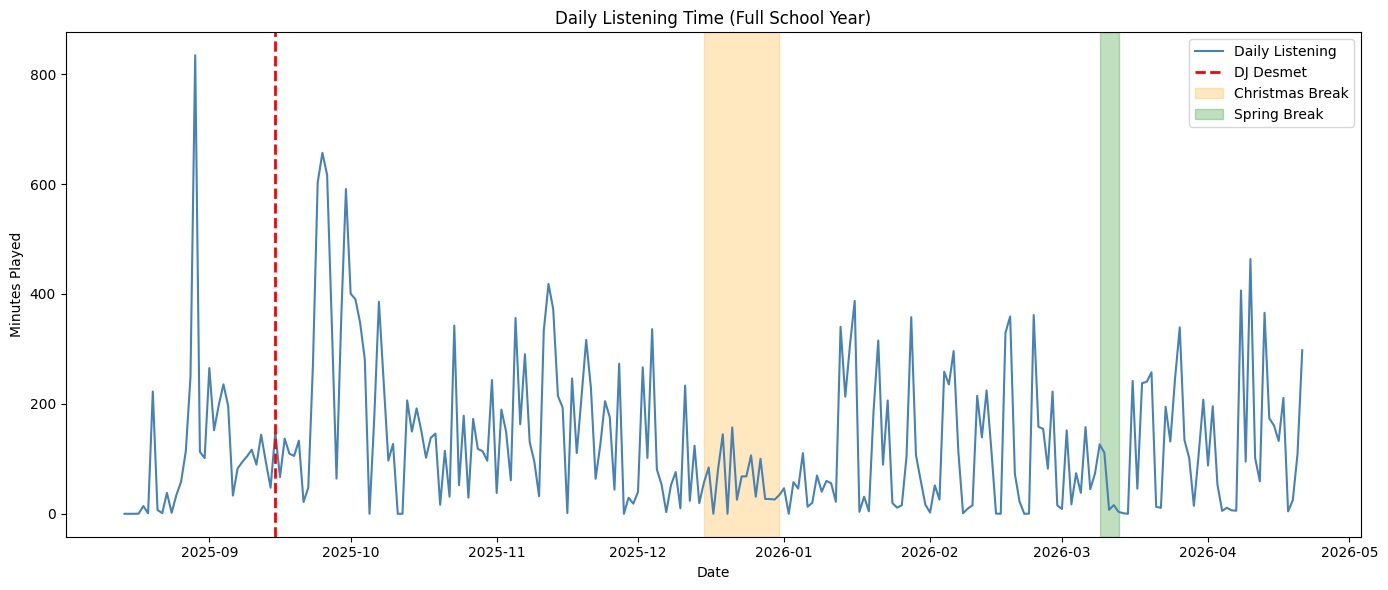

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

model_df = model_df.copy()

# Ensure datetime once
model_df["date_dt"] = pd.to_datetime(model_df["date"])

christmas_break = model_df.loc[
    model_df["event_name"] == "Christmas Break", "date_dt"
]
spring_break = model_df.loc[
    model_df["event_name"] == "Spring Break", "date_dt"
]

cb_start, cb_end = christmas_break.min(), christmas_break.max()
sb_start, sb_end = spring_break.min(), spring_break.max()

plt.figure(figsize=(14, 6))

plt.plot(
    model_df["date_dt"],
    model_df["minutes_played"],
    color="steelblue",
    label="Daily Listening"
)

dj_date = pd.to_datetime("2025-09-15")
plt.axvline(dj_date, color="red", linestyle="--", linewidth=2, label="DJ Desmet")

if pd.notna(cb_start) and pd.notna(cb_end):
    plt.axvspan(cb_start, cb_end, color="orange", alpha=0.25, label="Christmas Break")

if pd.notna(sb_start) and pd.notna(sb_end):
    plt.axvspan(sb_start, sb_end, color="green", alpha=0.25, label="Spring Break")

plt.title("Daily Listening Time (Full School Year)")
plt.xlabel("Date")
plt.ylabel("Minutes Played")
plt.legend()
plt.tight_layout()
plt.show()

### Understanding High vs. Low Listening Days

To study how predictable my listening habits are, I first split each day into either a high‑listening day or a low‑listening day based on whether I listened more or less than my usual amount. This gives me a simple yes/no label for each day.

Next, I pulled out basic calendar information from each date, such as the day of the week and the month. These details help reveal patterns like whether I listen more on certain weekdays or during certain parts of the school year. I also included whether the day happened before or after I became DJ Desmet, since that change affected my habits.

Using these pieces of information, I trained two different models to see if they could predict whether a day would be a high‑listening day. I tested both a k‑Nearest Neighbors model and a decision tree. After training them, I checked how accurate they were and compared their performance.

This part of the analysis shows how much of my listening behavior can be explained by simple calendar patterns and the shift that happened after becoming DJ Desmet.

### Hypothesis

I expect that the day of the week and the month influence how much music I listen to.

I also believe that a model should be able to predict high-listening days better than random guessing,
- Random guessing would be ~50%
- A model should be higher

In [ ]:
model_df = model_df.copy()

model_df["date_dt"] = pd.to_datetime(model_df["date"])

median_minutes = model_df["minutes_played"].median()
model_df["high_listening"] = (model_df["minutes_played"] > median_minutes).astype(int)

model_df["dayofweek"] = model_df["date_dt"].dt.dayofweek  # Monday=0
model_df["month"] = model_df["date_dt"].dt.month

X = model_df[["dayofweek", "month", "after_dj"]]
y = model_df["high_listening"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

accuracy, cm


(0.6666666666666666,
 array([[22,  8],
        [ 9, 12]]))

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

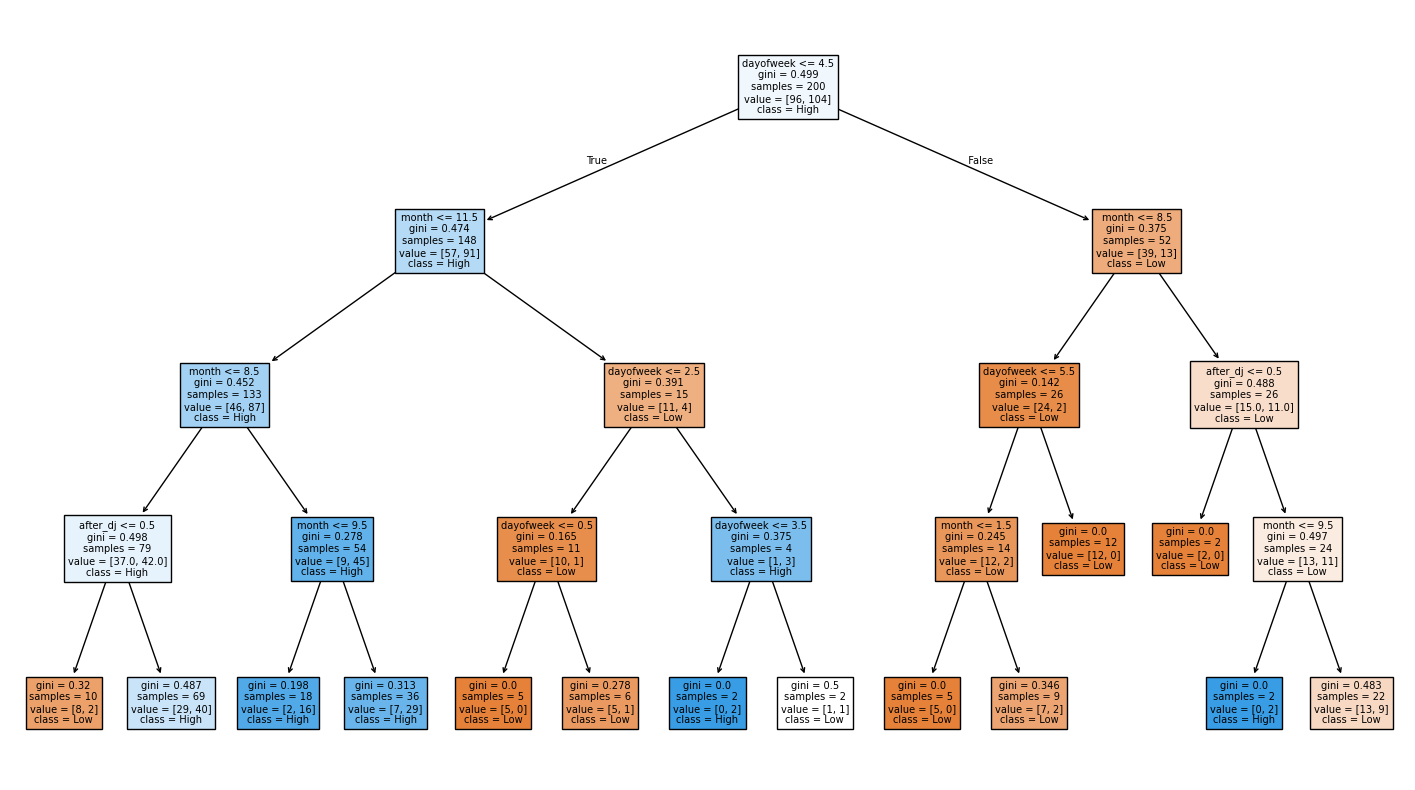

In [25]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
tree.plot_tree(dt, feature_names=X.columns, class_names=["Low", "High"], filled=True)
plt.show()


### Classification Results

The kNN model achieved an accuracy of **66.67%**, meaning it was able to correctly predict my listening level about two‑thirds of the time. This suggests that my listening habits follow some patterns, but there is still a fair amount of day‑to‑day variation.

The decision tree performed better, with an accuracy of **72.55%**. This indicates that my listening behavior does follow clear rules tied to the calendar—certain weekdays, certain months, and the shift after becoming DJ Desmet all influence how much I listen.

Overall, these results show that my listening habits are moderately predictable based on the school calendar, but not perfectly consistent, which makes sense for real human behavior.

In [26]:
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
tree_pred = dt.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print(f"kNN Accuracy: {round(knn_accuracy * 100, 2)}%")
print(f"Decision Tree Accuracy: {round(tree_accuracy * 100, 2)}%")

kNN Accuracy: 66.67%
Decision Tree Accuracy: 72.55%


### Conclusion

In this project, I developed a classification based approach to analyze my Spotify listening behavior and determine whether it could be predicted using features derived from the academic calendar and the DJ Desmet time period. I transformed daily listening data into a supervised learning problem by labeling days as either high or low listening based on the median minutes played, and then trained two classifiers: a k-Nearest Neighbors (kNN) model and a Decision Tree model.

The kNN classifier achieved an accuracy of **66.67%**, while the Decision Tree performed better with an accuracy of **72.55%**. This suggests that my listening behavior is not random, but instead follows identifiable patterns influenced by time-related factors such as day of the week, month, and whether the observation occurred before or after becoming DJ Desmet. The Decision Tree’s stronger performance also indicates that rule-based patterns (such as calendar effects) are more useful for explaining my listening habits than similarity based methods.

There are several ways this model could be improved. Adding additional features such as genre distribution, specific artist frequency, or longer-term listening trends could help capture more meaningful behavioral signals. Removing extreme outliers or using smoother time windows may also lead to more stable predictions.

From an ethical perspective, this type of analysis highlights how personal behavioral data can be used to infer patterns about an individual’s habits and routines. While this project only uses my own Spotify data, similar techniques applied at scale could raise privacy concerns if used without consent. For stakeholders such as streaming platforms, this kind of modeling could improve recommendation systems and user engagement, but it also raises questions about data transparency and user awareness of how their behavior is analyzed.

Overall, this project demonstrates that personal listening behavior is partially predictable using simple machine learning models, but still contains enough variability to reflect the complexity of human behavior.